# RMAB Comparison: Model B vs Model A

This notebook compares ICU allocation outcomes under two transition models:

- **Model B (clinical-only)**: `P_icu.npy`, `P_nonicu.npy` (82 states)
- **Model A (clinical + insurance)**: `P_icu_A.npy`, `P_nonicu_A.npy` (244 states)

We keep the **same clinical reward function** in both settings, then evaluate whether outcomes and allocation patterns differ.


## Method Summary

Same simulation design as `rmab_allocation_heuristic.ipynb`:

1. Build state reward from clinical bins (MAP, SpO2, GCS, Lactate), with death reward = -1
2. Compute a Q-lookahead RMAB index using value iteration
3. Simulate policies over multiple seeds:
   - `rmab_heuristic`
   - `sickest_first`
   - `random`
4. Compare cumulative reward, deaths, severity, occupancy
5. For Model A, inspect admission rates by insurance group


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.0)
np.set_printoptions(suppress=True, precision=4)

ROOT = Path('.')
N_CLINICAL = 81
INSURANCE_LABELS = {0: 'Medicaid', 1: 'Medicare', 2: 'Other'}

SEEDS = list(range(20))
POLICIES = ['rmab_heuristic', 'sickest_first', 'random']

SIM_CFG = {
    'n_patients': 300,
    'horizon': 90,
    'k_new_per_day': 20,
    'icu_length': 7,
}

SETTINGS = {
    'clinical_only': {
        'p_icu_path': ROOT / 'P_icu.npy',
        'p_nonicu_path': ROOT / 'P_nonicu.npy',
    },
    'clinical_plus_insurance': {
        'p_icu_path': ROOT / 'P_icu_A.npy',
        'p_nonicu_path': ROOT / 'P_nonicu_A.npy',
    },
}

for name, cfg in SETTINGS.items():
    assert cfg['p_icu_path'].exists(), f"Missing {cfg['p_icu_path']}"
    assert cfg['p_nonicu_path'].exists(), f"Missing {cfg['p_nonicu_path']}"

print('Ready. Seeds:', len(SEEDS), '| Policies:', POLICIES)


Ready. Seeds: 20 | Policies: ['rmab_heuristic', 'sickest_first', 'random']


In [46]:
def decode_state_base3(clinical_state: int):
    """Decode clinical state (0..80) into (map, spo2, gcs, lactate) bins in {0,1,2}."""
    map_bin = clinical_state // 27
    rem = clinical_state % 27
    spo2_bin = rem // 9
    rem = rem % 9
    gcs_bin = rem // 3
    lactate_bin = rem % 3
    return map_bin, spo2_bin, gcs_bin, lactate_bin


def extract_clinical_state(state: int, n_states: int, death_state: int) -> int:
    """
    Map a full state index to its clinical sub-state index.

    - Model B (82): state is already clinical (0..80), death=81
    - Model A (244): state = insurance_bin * 81 + clinical_state, death=243
    """
    if state == death_state:
        raise ValueError('Death state has no clinical decomposition')

    n_live = n_states - 1
    if n_live == N_CLINICAL:
        return state
    if n_live % N_CLINICAL == 0:
        return state % N_CLINICAL

    raise ValueError(f'Unsupported state-space layout: n_states={n_states}')


def build_heuristic_reward(n_states: int, death_state: int, weights=None, death_reward=-1.0):
    """Same reward logic as RMAB heuristic notebook, applied consistently in both settings."""
    if weights is None:
        weights = {'map': 1.0, 'spo2': 1.2, 'gcs': 1.3, 'lactate': 1.0}

    wsum = sum(weights.values())
    severity = np.zeros(n_states, dtype=float)
    reward = np.zeros(n_states, dtype=float)

    for s in range(n_states):
        if s == death_state:
            severity[s] = 1.0
            reward[s] = death_reward
            continue

        clinical_state = extract_clinical_state(s, n_states=n_states, death_state=death_state)
        map_bin, spo2_bin, gcs_bin, lactate_bin = decode_state_base3(clinical_state)

        b_map = 2 - map_bin
        b_spo2 = 2 - spo2_bin
        b_gcs = 2 - gcs_bin
        b_lac = 2 - lactate_bin

        sev = (
            weights['map'] * b_map
            + weights['spo2'] * b_spo2
            + weights['gcs'] * b_gcs
            + weights['lactate'] * b_lac
        ) / (2.0 * wsum)

        severity[s] = sev
        reward[s] = 1.0 - sev

    return severity, reward


def compute_q_lookahead_index(p_icu, p_nonicu, reward, death_state, gamma=0.95, tol=1e-8, max_iter=2000):
    """Compute Q-lookahead state score: Q(s, ICU) - Q(s, nonICU)."""
    v = np.zeros_like(reward, dtype=float)

    for it in range(max_iter):
        q_icu = p_icu @ (reward + gamma * v)
        q_nonicu = p_nonicu @ (reward + gamma * v)
        v_new = np.maximum(q_icu, q_nonicu)

        delta = np.max(np.abs(v_new - v))
        v = v_new
        if delta < tol:
            break

    q_icu = p_icu @ (reward + gamma * v)
    q_nonicu = p_nonicu @ (reward + gamma * v)
    index_q = q_icu - q_nonicu
    index_q[death_state] = -np.inf

    return v, q_icu, q_nonicu, index_q, it + 1, float(delta)


def default_initial_distribution(n_states: int, death_state: int):
    """
    Same initialization spirit as the original notebook.

    For Model A, clinical anchors are spread across all insurance bins.
    """
    p = np.zeros(n_states, dtype=float)
    n_live = n_states - 1

    anchors = [53, 44, 52, 50, 26]
    base_weights = np.array([0.45, 0.20, 0.15, 0.10, 0.10], dtype=float)

    groups = 1
    if n_live % N_CLINICAL == 0:
        groups = n_live // N_CLINICAL

    valid_anchors = [s for s in anchors if 0 <= s < N_CLINICAL]
    anchor_weights = base_weights[: len(valid_anchors)]
    anchor_weights = anchor_weights / anchor_weights.sum()

    p[:death_state] = 1e-6  # smoothing

    if groups == 1 and n_live == N_CLINICAL:
        for clin, w in zip(valid_anchors, anchor_weights):
            p[clin] += w
    else:
        for clin, w in zip(valid_anchors, anchor_weights):
            for g in range(groups):
                state = g * N_CLINICAL + clin
                if state < death_state:
                    p[state] += w / groups

    p[death_state] = 0.0
    p = p / p.sum()
    return p


def pick_admissions(states, in_icu, k_new, policy, index_q, severity, death_state, rng):
    eligible = np.where((~in_icu) & (states != death_state))[0]
    if len(eligible) == 0 or k_new <= 0:
        return np.array([], dtype=int), eligible

    k = min(k_new, len(eligible))

    if policy == 'rmab_heuristic':
        scores = index_q[states[eligible]]
        chosen = eligible[np.argsort(scores)[-k:]]
    elif policy == 'sickest_first':
        scores = severity[states[eligible]]
        chosen = eligible[np.argsort(scores)[-k:]]
    elif policy == 'random':
        chosen = rng.choice(eligible, size=k, replace=False)
    else:
        raise ValueError(f'Unknown policy: {policy}')

    return chosen, eligible


def sample_next_states(states, in_icu, p_icu, p_nonicu, death_state, rng):
    n_states = p_icu.shape[0]
    next_states = states.copy()

    for i, s in enumerate(states):
        if s == death_state:
            next_states[i] = death_state
            continue
        probs = p_icu[s] if in_icu[i] else p_nonicu[s]
        next_states[i] = int(rng.choice(n_states, p=probs))

    return next_states


def simulate_rmab(
    p_icu,
    p_nonicu,
    reward,
    severity,
    index_q,
    death_state,
    n_patients=300,
    horizon=90,
    k_new_per_day=20,
    icu_length=7,
    policy='rmab_heuristic',
    seed=0,
    init_probs=None,
):
    rng = np.random.default_rng(seed)
    n_states = p_icu.shape[0]

    if init_probs is None:
        init_probs = default_initial_distribution(n_states, death_state)

    states = rng.choice(n_states, size=n_patients, p=init_probs)
    icu_days_remaining = np.zeros(n_patients, dtype=int)

    n_live = n_states - 1
    has_insurance_dim = (n_live % N_CLINICAL == 0) and (n_live // N_CLINICAL > 1)
    n_bins = (n_live // N_CLINICAL) if has_insurance_dim else 0

    eligible_by_bin = np.zeros(n_bins, dtype=int)
    admits_by_bin = np.zeros(n_bins, dtype=int)
    deaths_from_bin = np.zeros(n_bins, dtype=int)

    history = []

    for t in range(horizon):
        in_icu_before = icu_days_remaining > 0

        admits, eligible = pick_admissions(
            states=states,
            in_icu=in_icu_before,
            k_new=k_new_per_day,
            policy=policy,
            index_q=index_q,
            severity=severity,
            death_state=death_state,
            rng=rng,
        )
        icu_days_remaining[admits] = icu_length

        if has_insurance_dim:
            if len(eligible) > 0:
                bins = states[eligible] // N_CLINICAL
                for b in range(n_bins):
                    eligible_by_bin[b] += int(np.sum(bins == b))
            if len(admits) > 0:
                bins_admit = states[admits] // N_CLINICAL
                for b in range(n_bins):
                    admits_by_bin[b] += int(np.sum(bins_admit == b))

        in_icu_now = icu_days_remaining > 0

        daily_reward = float(reward[states].sum())
        deaths = int(np.sum(states == death_state))
        mean_sev = float(np.mean(severity[states]))

        history.append({
            'day': t,
            'policy': policy,
            'daily_reward': daily_reward,
            'cumulative_reward': daily_reward if t == 0 else history[-1]['cumulative_reward'] + daily_reward,
            'deaths': deaths,
            'mean_severity': mean_sev,
            'icu_occupancy': int(np.sum(in_icu_now)),
            'new_admissions': int(len(admits)),
        })

        next_states = sample_next_states(
            states=states,
            in_icu=in_icu_now,
            p_icu=p_icu,
            p_nonicu=p_nonicu,
            death_state=death_state,
            rng=rng,
        )

        if has_insurance_dim:
            newly_dead = (states != death_state) & (next_states == death_state)
            if np.any(newly_dead):
                prior_bins = states[newly_dead] // N_CLINICAL
                for b in range(n_bins):
                    deaths_from_bin[b] += int(np.sum(prior_bins == b))

        states = next_states

        icu_days_remaining = np.maximum(icu_days_remaining - 1, 0)
        icu_days_remaining[states == death_state] = 0

    aux = {}
    if has_insurance_dim:
        for b in range(n_bins):
            label = INSURANCE_LABELS.get(b, f'bin{b}')
            aux[f'eligible_{label}'] = int(eligible_by_bin[b])
            aux[f'admits_{label}'] = int(admits_by_bin[b])
            aux[f'admit_rate_{label}'] = float(admits_by_bin[b] / eligible_by_bin[b]) if eligible_by_bin[b] > 0 else np.nan
            aux[f'new_deaths_{label}'] = int(deaths_from_bin[b])

    return pd.DataFrame(history), aux


## Run Experiments

This cell runs all settings × policies × seeds and keeps everything in-memory for plotting.


In [47]:
def run_setting(name, p_icu_path, p_nonicu_path, seeds, policies):
    p_icu = np.load(p_icu_path)
    p_nonicu = np.load(p_nonicu_path)

    if p_icu.shape != p_nonicu.shape:
        raise ValueError(f'[{name}] Shape mismatch: {p_icu.shape} vs {p_nonicu.shape}')

    n_states = p_icu.shape[0]
    death_state = n_states - 1

    severity, reward = build_heuristic_reward(n_states=n_states, death_state=death_state)
    _, _, _, index_q, n_vi_iters, vi_delta = compute_q_lookahead_index(
        p_icu=p_icu,
        p_nonicu=p_nonicu,
        reward=reward,
        death_state=death_state,
    )

    print(f'[{name}] states={n_states}, death_state={death_state}, VI_iters={n_vi_iters}, delta={vi_delta:.2e}')

    rows = []
    traj_rows = []
    for policy in policies:
        for seed in seeds:
            traj, aux = simulate_rmab(
                p_icu=p_icu,
                p_nonicu=p_nonicu,
                reward=reward,
                severity=severity,
                index_q=index_q,
                death_state=death_state,
                policy=policy,
                seed=seed,
                **SIM_CFG,
            )

            final = traj.iloc[-1]
            row = {
                'setting': name,
                'policy': policy,
                'seed': seed,
                'cumulative_reward': float(final['cumulative_reward']),
                'deaths': float(final['deaths']),
                'mean_severity': float(final['mean_severity']),
                'avg_daily_reward': float(traj['daily_reward'].mean()),
                'mean_icu_occupancy': float(traj['icu_occupancy'].mean()),
                'total_new_admissions': float(traj['new_admissions'].sum()),
            }
            row.update(aux)
            rows.append(row)

            traj_tmp = traj.copy()
            traj_tmp['setting'] = name
            traj_tmp['policy'] = policy
            traj_tmp['seed'] = seed
            traj_rows.append(traj_tmp)

    return pd.DataFrame(rows), pd.concat(traj_rows, ignore_index=True)

all_results = []
all_trajectories = []
for setting_name, cfg in SETTINGS.items():
    df_setting, traj_setting = run_setting(
        name=setting_name,
        p_icu_path=cfg['p_icu_path'],
        p_nonicu_path=cfg['p_nonicu_path'],
        seeds=SEEDS,
        policies=POLICIES,
    )
    all_results.append(df_setting)
    all_trajectories.append(traj_setting)

results = pd.concat(all_results, ignore_index=True)
trajectories = pd.concat(all_trajectories, ignore_index=True)

print('results shape:', results.shape)
print('trajectories shape:', trajectories.shape)
results.head()


[clinical_only] states=82, death_state=81, VI_iters=361, delta=9.56e-09
[clinical_plus_insurance] states=244, death_state=243, VI_iters=361, delta=9.56e-09
results shape: (120, 21)
trajectories shape: (10800, 10)


,setting,policy,seed,cumulative_reward,deaths,mean_severity,avg_daily_reward,mean_icu_occupancy,total_new_admissions,eligible_Medicaid,...,admit_rate_Medicaid,new_deaths_Medicaid,eligible_Medicare,admits_Medicare,admit_rate_Medicare,new_deaths_Medicare,eligible_Other,admits_Other,admit_rate_Other,new_deaths_Other
0,clinical_only,rmab_heuristic,0,12946.244444,99.0,0.510037,143.847160,133.366667,1800.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,clinical_only,rmab_heuristic,1,11306.055556,108.0,0.535741,125.622840,132.744444,1800.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,clinical_only,rmab_heuristic,2,12510.311111,100.0,0.511333,139.003457,133.011111,1800.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,clinical_only,rmab_heuristic,3,12111.811111,93.0,0.489481,134.575679,133.366667,1800.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,clinical_only,rmab_heuristic,4,11809.022222,100.0,0.523185,131.211358,133.088889,1800.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Summary Tables


In [48]:
summary = (
    results.groupby(['setting', 'policy'])[['cumulative_reward', 'deaths', 'mean_severity', 'avg_daily_reward', 'mean_icu_occupancy']]
    .agg(['mean', 'std'])
    .round(3)
)
summary


cumulative_reward            deaths  \
                                                    mean       std    mean   
setting                 policy                                               
clinical_only           random                  -277.308   771.056  200.05   
                        rmab_heuristic         12214.884   837.853   99.10   
                        sickest_first           7715.703  1043.109  148.00   
clinical_plus_insurance random                  5976.089  1014.991  152.70   
                        rmab_heuristic         19436.916   448.447   23.05   
                        sickest_first           8556.884  1304.680  133.90   

                                              mean_severity         \
                                          std          mean    std   
setting                 policy                                       
clinical_only           random          5.698         0.756  0.017   
                        rmab_heuristic  6.988         0.509  0.019   
                        sickest_first   9.995         0.621  0.028   
clinical_plus_insurance random          6.010         0.614  0.016   
                        rmab_heuristic  4.084         0.253  0.011   
                        sickest_first   9.580         0.560  0.027   

                                       avg_daily_reward          \
                                                   mean     std   
setting                 policy                                    
clinical_only           random                   -3.081   8.567   
                        rmab_heuristic          135.721   9.309   
                        sickest_first            85.730  11.590   
clinical_plus_insurance random                   66.401  11.278   
                        rmab_heuristic          215.966   4.983   
                        sickest_first            95.076  14.496   

                                       mean_icu_occupancy         
                                                     mean    std  
setting                 policy                                    
clinical_only           random                    123.737  2.334  
                        rmab_heuristic            133.222  0.249  
                        sickest_first             131.037  0.403  
clinical_plus_insurance random                    132.619  0.313  
                        rmab_heuristic            134.994  0.118  
                        sickest_first             131.909  0.528

In [49]:
rmab_only = (
    results[results['policy'] == 'rmab_heuristic']
    .groupby('setting')[['cumulative_reward', 'deaths', 'avg_daily_reward', 'mean_severity', 'mean_icu_occupancy']]
    .mean()
)

if {'clinical_only', 'clinical_plus_insurance'}.issubset(rmab_only.index):
    rmab_delta = (rmab_only.loc['clinical_plus_insurance'] - rmab_only.loc['clinical_only']).to_frame('delta_A_minus_B')
else:
    rmab_delta = pd.DataFrame()

rmab_delta


,delta_A_minus_B
cumulative_reward,7222.031667
deaths,-76.050000
avg_daily_reward,80.244796
mean_severity,-0.256157
mean_icu_occupancy,1.772778


## Graphs: Utility and Clinical Outcomes


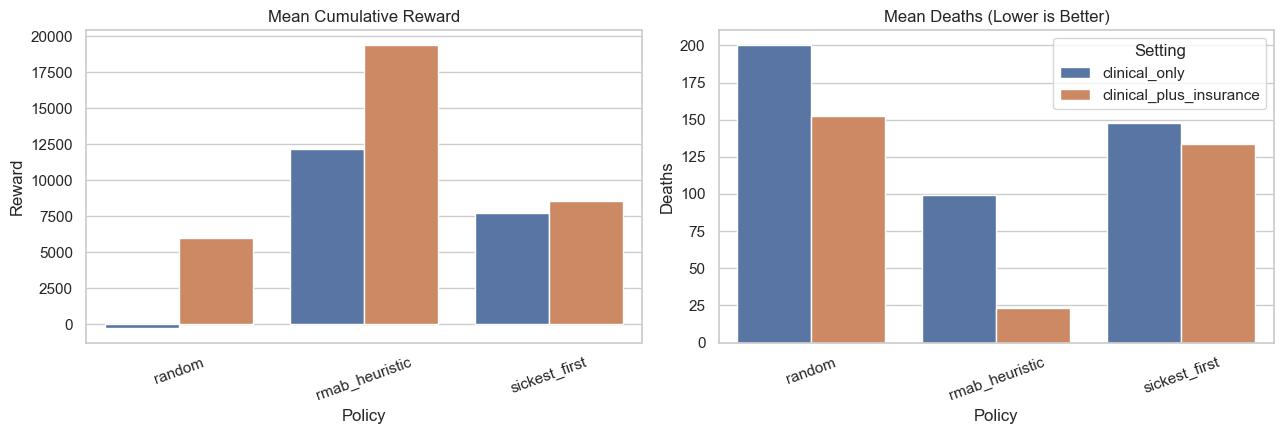

In [50]:
plot_df = (
    results.groupby(['setting', 'policy'])[['cumulative_reward', 'deaths', 'avg_daily_reward', 'mean_severity']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=plot_df, x='policy', y='cumulative_reward', hue='setting', ax=axes[0])
axes[0].set_title('Mean Cumulative Reward')
axes[0].set_xlabel('Policy')
axes[0].set_ylabel('Reward')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=plot_df, x='policy', y='deaths', hue='setting', ax=axes[1])
axes[1].set_title('Mean Deaths (Lower is Better)')
axes[1].set_xlabel('Policy')
axes[1].set_ylabel('Deaths')
axes[1].tick_params(axis='x', rotation=20)

handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend(handles, labels, title='Setting', loc='best')

plt.tight_layout()
plt.show()


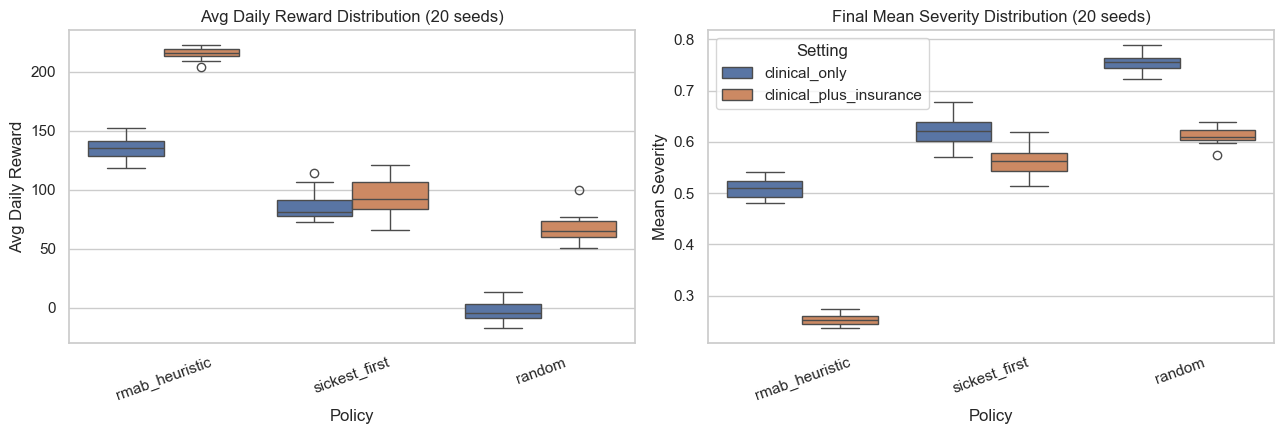

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=results, x='policy', y='avg_daily_reward', hue='setting', ax=axes[0])
axes[0].set_title('Avg Daily Reward Distribution (20 seeds)')
axes[0].set_xlabel('Policy')
axes[0].set_ylabel('Avg Daily Reward')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=results, x='policy', y='mean_severity', hue='setting', ax=axes[1])
axes[1].set_title('Final Mean Severity Distribution (20 seeds)')
axes[1].set_xlabel('Policy')
axes[1].set_ylabel('Mean Severity')
axes[1].tick_params(axis='x', rotation=20)

handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend(handles, labels, title='Setting', loc='best')

plt.tight_layout()
plt.show()


## Reward Curves with Uncertainty (Mean ± 1 Std)

These plots show **time trajectories** across seeds, with shaded bands indicating variability.


In [52]:
traj_stats = (
    trajectories
    .groupby(['setting', 'policy', 'day'])[['daily_reward', 'cumulative_reward']]
    .agg(['mean', 'std'])
    .reset_index()
)

# Flatten MultiIndex columns
traj_stats.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in traj_stats.columns
]

traj_stats.head()


,setting,policy,day,daily_reward_mean,daily_reward_std,cumulative_reward_mean,cumulative_reward_std
0,clinical_only,random,0,246.097778,1.316900,246.097778,1.316900
1,clinical_only,random,1,195.144444,10.423192,441.242222,11.200348
2,clinical_only,random,2,191.078889,10.677054,632.321111,21.675264
3,clinical_only,random,3,185.176667,11.201566,817.497778,32.473332
4,clinical_only,random,4,179.880556,11.740825,997.378333,43.727411


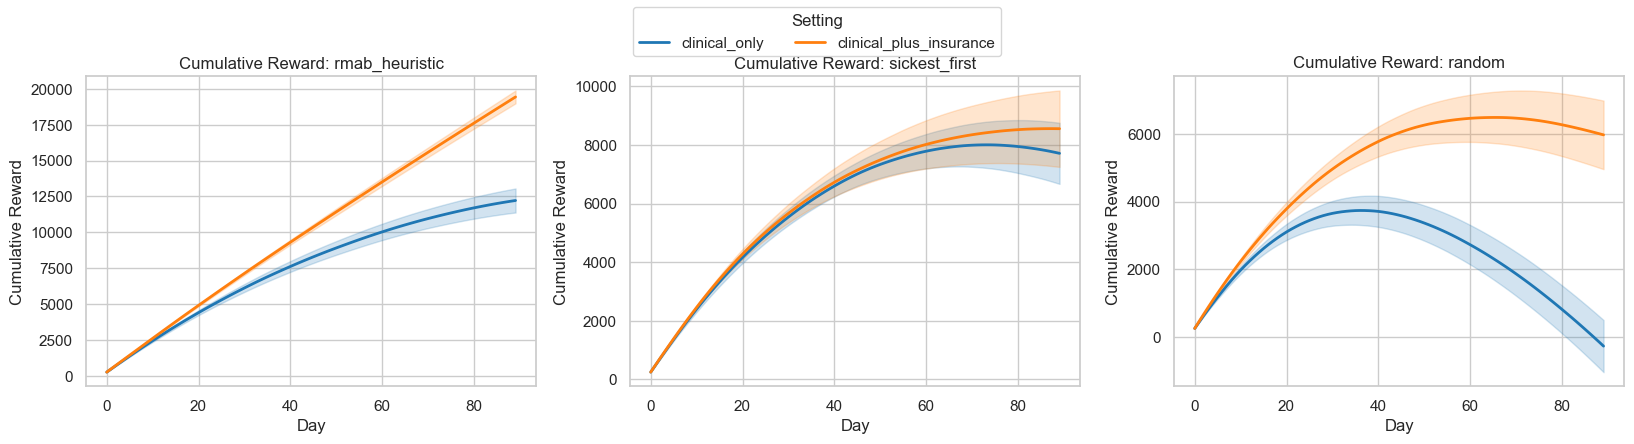

In [53]:
palette = {
    'clinical_only': '#1f77b4',
    'clinical_plus_insurance': '#ff7f0e',
}

fig, axes = plt.subplots(1, len(POLICIES), figsize=(5.5 * len(POLICIES), 4.5), sharey=False)
if len(POLICIES) == 1:
    axes = [axes]

for ax, policy in zip(axes, POLICIES):
    for setting in SETTINGS.keys():
        sub = traj_stats[(traj_stats['policy'] == policy) & (traj_stats['setting'] == setting)].sort_values('day')
        x = sub['day'].to_numpy()
        y = sub['cumulative_reward_mean'].to_numpy()
        s = sub['cumulative_reward_std'].to_numpy()

        ax.plot(x, y, label=setting, color=palette[setting], linewidth=2)
        ax.fill_between(x, y - s, y + s, color=palette[setting], alpha=0.2)

    ax.set_title(f'Cumulative Reward: {policy}')
    ax.set_xlabel('Day')
    ax.set_ylabel('Cumulative Reward')

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, title='Setting')
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


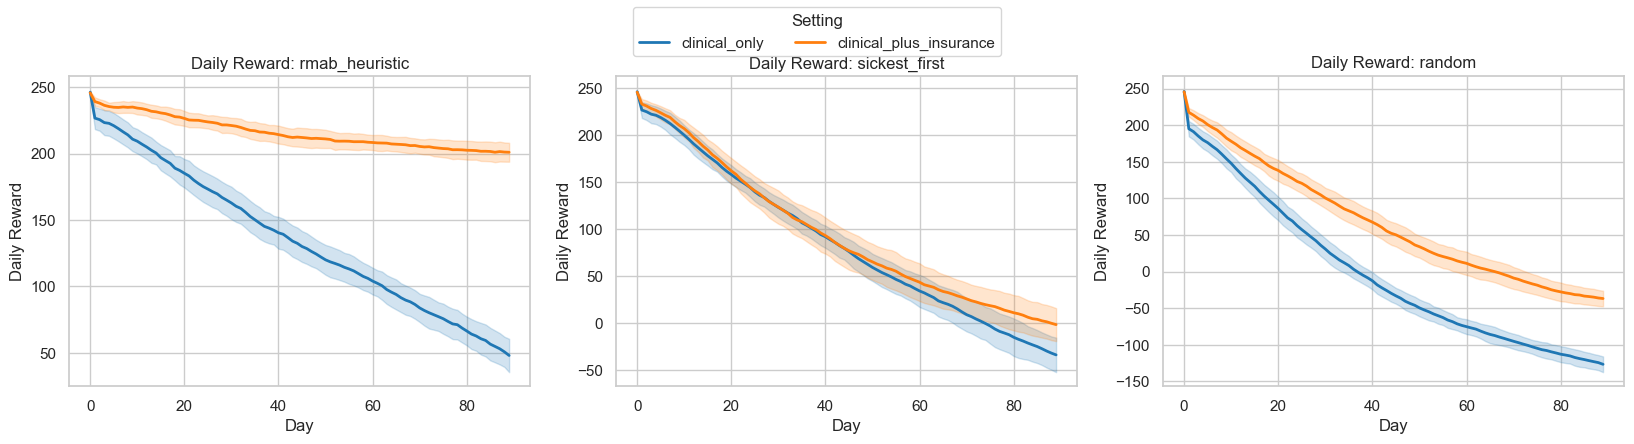

In [54]:
fig, axes = plt.subplots(1, len(POLICIES), figsize=(5.5 * len(POLICIES), 4.5), sharey=False)
if len(POLICIES) == 1:
    axes = [axes]

for ax, policy in zip(axes, POLICIES):
    for setting in SETTINGS.keys():
        sub = traj_stats[(traj_stats['policy'] == policy) & (traj_stats['setting'] == setting)].sort_values('day')
        x = sub['day'].to_numpy()
        y = sub['daily_reward_mean'].to_numpy()
        s = sub['daily_reward_std'].to_numpy()

        ax.plot(x, y, label=setting, color=palette[setting], linewidth=2)
        ax.fill_between(x, y - s, y + s, color=palette[setting], alpha=0.2)

    ax.set_title(f'Daily Reward: {policy}')
    ax.set_xlabel('Day')
    ax.set_ylabel('Daily Reward')

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, title='Setting')
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


## Why Can Model A Show Better Reward?

Even with the same **clinical reward function**, utility can improve if the transition model changes.
This section checks one key mechanism: differences in death-transition probabilities.


In [55]:
P_icu_B = np.load(SETTINGS['clinical_only']['p_icu_path'])
P_non_B = np.load(SETTINGS['clinical_only']['p_nonicu_path'])
P_icu_A = np.load(SETTINGS['clinical_plus_insurance']['p_icu_path'])
P_non_A = np.load(SETTINGS['clinical_plus_insurance']['p_nonicu_path'])

D_B = P_icu_B.shape[0] - 1
D_A = P_icu_A.shape[0] - 1

rows = []
for c in range(N_CLINICAL):
    b_icu = P_icu_B[c, D_B]
    b_non = P_non_B[c, D_B]

    a_icu_vals = [P_icu_A[g * N_CLINICAL + c, D_A] for g in range(3)]
    a_non_vals = [P_non_A[g * N_CLINICAL + c, D_A] for g in range(3)]

    rows.append({
        'clinical_state': c,
        'B_icu_death': b_icu,
        'B_non_death': b_non,
        'Aavg_icu_death': float(np.mean(a_icu_vals)),
        'Aavg_non_death': float(np.mean(a_non_vals)),
        'AminusB_icu_death': float(np.mean(a_icu_vals) - b_icu),
        'AminusB_non_death': float(np.mean(a_non_vals) - b_non),
    })

death_cmp = pd.DataFrame(rows)

death_cmp[['B_icu_death', 'Aavg_icu_death', 'B_non_death', 'Aavg_non_death']].describe().loc[['mean', '50%', 'std']]


,B_icu_death,Aavg_icu_death,B_non_death,Aavg_non_death
mean,0.016750,0.011298,0.034359,0.011943
50%,0.012195,0.004098,0.012195,0.004098
std,0.040613,0.049745,0.154673,0.051903


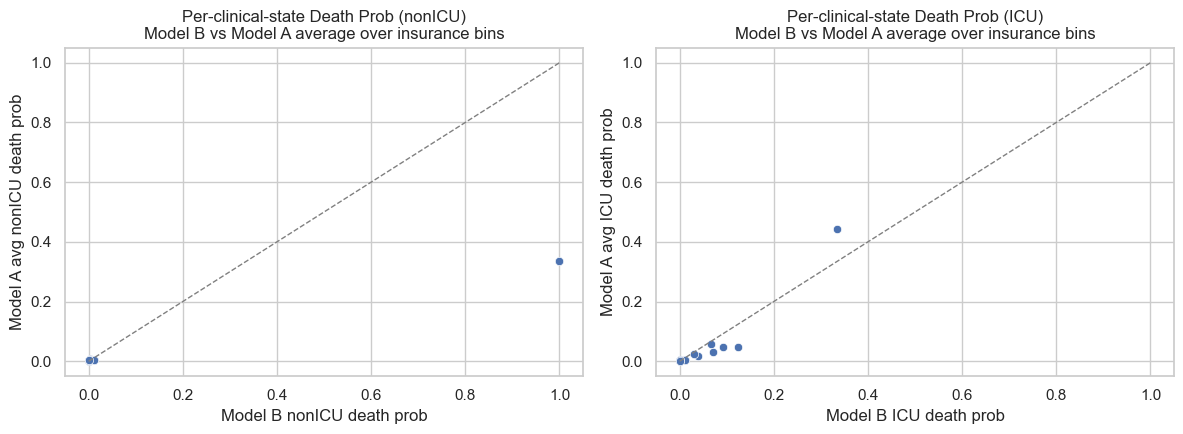

Mean A-B death-prob difference (ICU): -0.005452
Mean A-B death-prob difference (nonICU): -0.022415
Fraction clinical states where Aavg < B (nonICU): 0.8148


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(data=death_cmp, x='B_non_death', y='Aavg_non_death', ax=axes[0])
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
axes[0].set_title('Per-clinical-state Death Prob (nonICU)\nModel B vs Model A average over insurance bins')
axes[0].set_xlabel('Model B nonICU death prob')
axes[0].set_ylabel('Model A avg nonICU death prob')

sns.scatterplot(data=death_cmp, x='B_icu_death', y='Aavg_icu_death', ax=axes[1])
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
axes[1].set_title('Per-clinical-state Death Prob (ICU)\nModel B vs Model A average over insurance bins')
axes[1].set_xlabel('Model B ICU death prob')
axes[1].set_ylabel('Model A avg ICU death prob')

plt.tight_layout()
plt.show()

print('Mean A-B death-prob difference (ICU):', round(death_cmp['AminusB_icu_death'].mean(), 6))
print('Mean A-B death-prob difference (nonICU):', round(death_cmp['AminusB_non_death'].mean(), 6))
print('Fraction clinical states where Aavg < B (nonICU):', round((death_cmp['AminusB_non_death'] < 0).mean(), 4))


In [57]:
# Check original anchor clinical states used by initialization.
anchors = [53, 44, 52, 50, 26]
anchor_rows = []
for c in anchors:
    row = {
        'clinical_state': c,
        'B_non_death': P_non_B[c, D_B],
        'B_icu_death': P_icu_B[c, D_B],
    }
    for g, label in INSURANCE_LABELS.items():
        s = g * N_CLINICAL + c
        row[f'A_non_death_{label}'] = P_non_A[s, D_A]
        row[f'A_icu_death_{label}'] = P_icu_A[s, D_A]
    anchor_rows.append(row)

pd.DataFrame(anchor_rows).round(6)


,clinical_state,B_non_death,B_icu_death,A_non_death_Medicaid,A_icu_death_Medicaid,A_non_death_Medicare,A_icu_death_Medicare,A_non_death_Other,A_icu_death_Other
0,53,0.002558,0.000000,0.019231,0.000000,0.000000,0.00,0.001842,0.0
1,44,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.0
2,52,0.000000,0.000000,0.000000,0.004098,0.000000,0.00,0.000000,0.0
3,50,1.000000,0.000000,0.004098,0.000000,0.004098,0.00,1.000000,0.0
4,26,0.000000,0.038462,0.000000,0.000000,0.000000,0.05,0.004098,0.0


## Model A Fairness Lens: Insurance Allocation Patterns

These diagnostics are only available for Model A (`clinical_plus_insurance`) because the state includes insurance bins.


In [58]:
ins_df = results[results['setting'] == 'clinical_plus_insurance'].copy()

admit_rate_cols = [c for c in ins_df.columns if c.startswith('admit_rate_')]
insurance_admit_rates = ins_df.groupby('policy')[admit_rate_cols].mean().round(4)
insurance_admit_rates


,admit_rate_Medicaid,admit_rate_Medicare,admit_rate_Other
policy,,,
random,0.2137,0.1767,0.2353
rmab_heuristic,0.1535,0.0302,0.1611
sickest_first,0.2809,0.1963,0.1386


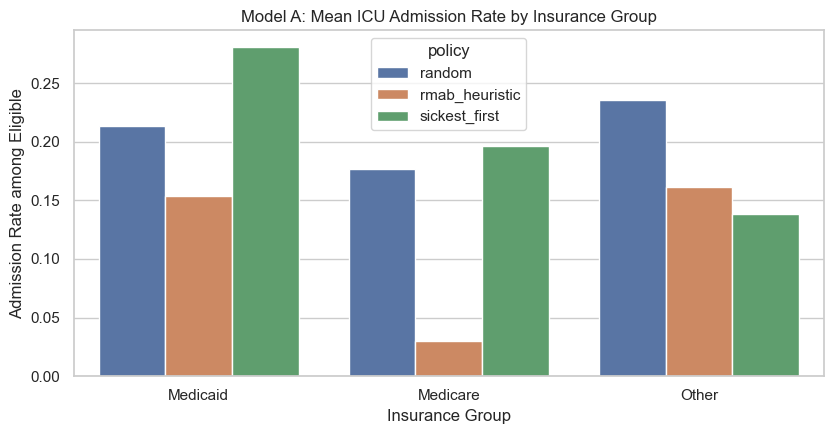

In [59]:
long_admit = (
    insurance_admit_rates.reset_index()
    .melt(id_vars='policy', var_name='group', value_name='admit_rate')
)
long_admit['group'] = long_admit['group'].str.replace('admit_rate_', '', regex=False)

plt.figure(figsize=(8.5, 4.5))
sns.barplot(data=long_admit, x='group', y='admit_rate', hue='policy')
plt.title('Model A: Mean ICU Admission Rate by Insurance Group')
plt.xlabel('Insurance Group')
plt.ylabel('Admission Rate among Eligible')
plt.tight_layout()
plt.show()


In [60]:
# Deaths per eligible patient by insurance group (Model A)
death_rate_rows = []
for policy, g in ins_df.groupby('policy'):
    for grp in ['Medicaid', 'Medicare', 'Other']:
        elig = g[f'eligible_{grp}'].mean()
        dth = g[f'new_deaths_{grp}'].mean()
        death_rate_rows.append({
            'policy': policy,
            'group': grp,
            'death_per_eligible': (dth / elig) if elig > 0 else np.nan,
        })

death_rate_df = pd.DataFrame(death_rate_rows)
death_rate_df_pivot = death_rate_df.pivot(index='policy', columns='group', values='death_per_eligible').round(5)
death_rate_df_pivot


group,Medicaid,Medicare,Other
policy,,,
random,0.00662,0.03306,0.01705
rmab_heuristic,0.00045,0.00334,0.00089
sickest_first,0.01178,0.03749,0.00234


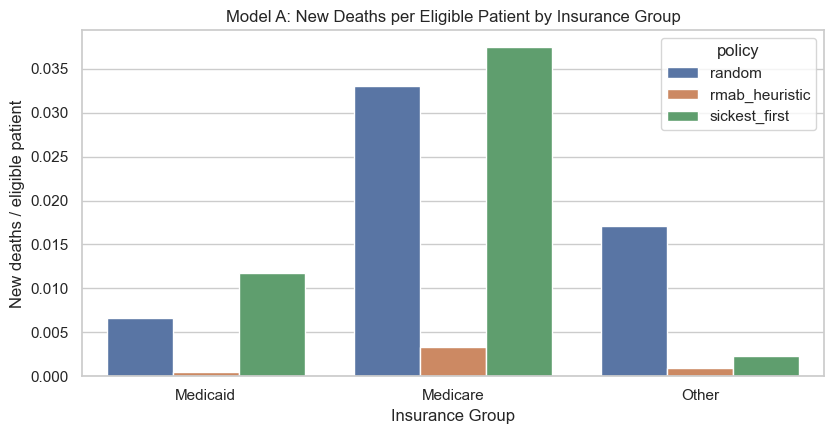

In [61]:
plt.figure(figsize=(8.5, 4.5))
sns.barplot(data=death_rate_df, x='group', y='death_per_eligible', hue='policy')
plt.title('Model A: New Deaths per Eligible Patient by Insurance Group')
plt.xlabel('Insurance Group')
plt.ylabel('New deaths / eligible patient')
plt.tight_layout()
plt.show()
